# Motivation and Inspiration: 

# Methodology: 

# Exploratory Data Analysis: 

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scripts import data_cleaning

                    Player  Season Ending Year   Age Team  Games  \
2      Kareem Abdul-Jabbar              1980.0  32.0  LAL   82.0   
3            Tom Abernethy              1980.0  25.0  GSW   67.0   
4              Alvan Adams              1980.0  25.0  PHO   75.0   
5           Tiny Archibald              1980.0  31.0  BOS   80.0   
6            Dennis Awtrey              1980.0  31.0  CHI   26.0   
...                    ...                 ...   ...  ...    ...   
21633         Delon Wright              2025.0  32.0  MIL   40.0   
21634   Guerschon Yabusele              2025.0  29.0  PHI   70.0   
21635         Jahmir Young              2025.0  24.0  CHI    6.0   
21636           Trae Young              2025.0  26.0  ATL   76.0   
21637          Ivica Zubac              2025.0  27.0  LAC   80.0   

       Minutes per game  FGA per game  2PA per game  3PA per game  \
2             38.329268     16.865854     16.853659      0.012195   
3             18.238806      4.746269      4.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


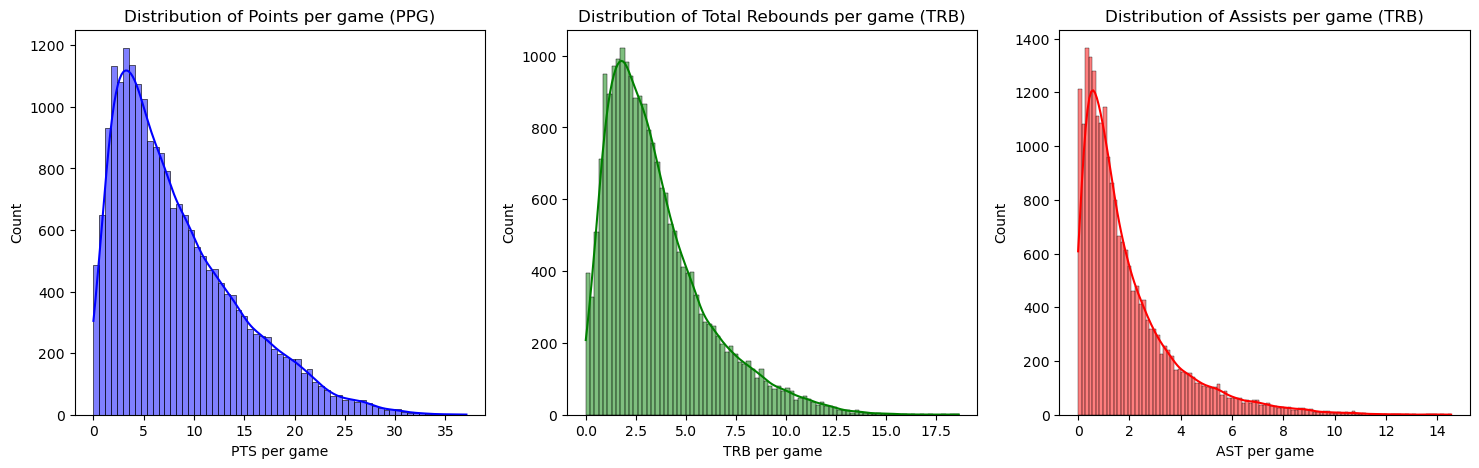

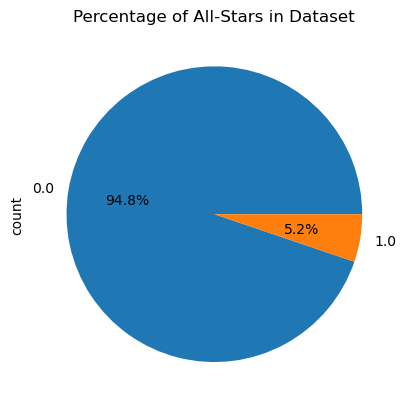

In [10]:
# Look at the distribution of Points
df = data_cleaning.df_clean

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data =df, x='PTS per game', kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Points per game (PPG)')

sns.histplot(data =df, x='TRB per game', kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Total Rebounds per game (TRB)')

sns.histplot(data =df, x='AST per game', kde=True, ax=axes[2], color='red')
axes[2].set_title('Distribution of Assists per game (TRB)')

plt.show()

df['All Star'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentage of All-Stars in Dataset')
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


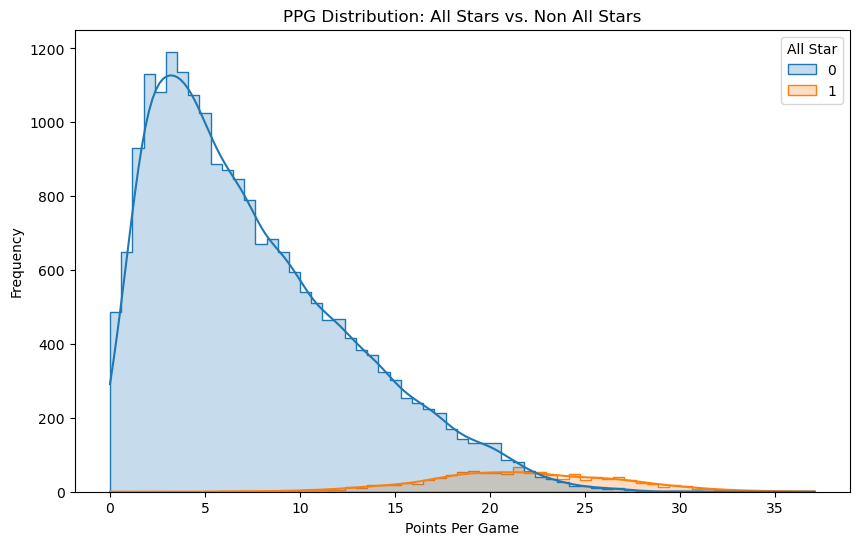

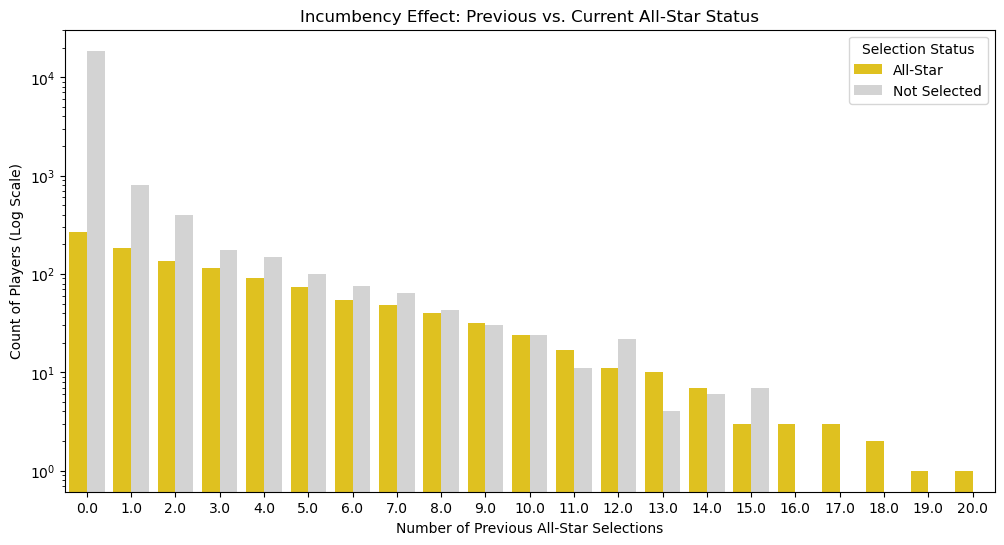

In [21]:
plt.figure(figsize=(10, 6))
# 'hue' splits the data by the All-Star column
sns.histplot(data=df, x='PTS per game', hue='All Star', kde=True, element="step")

plt.title('PPG Distribution: All Stars vs. Non All Stars')
plt.xlabel('Points Per Game')
plt.ylabel('Frequency')
plt.show()


#  temporary column for plotting with string labels
df['Selection Status'] = df['All Star'].map({0: 'Not Selected', 1: 'All-Star'})
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='Prev All Stars', hue='Selection Status', 
              palette={'Not Selected': 'lightgrey', 'All-Star': 'gold'})

plt.yscale('log')
plt.title('Incumbency Effect: Previous vs. Current All-Star Status')
plt.xlabel('Number of Previous All-Star Selections')
plt.ylabel('Count of Players (Log Scale)')

# remove the temporary column after plotting
df.drop('Selection Status', axis=1, inplace=True)

plt.show()

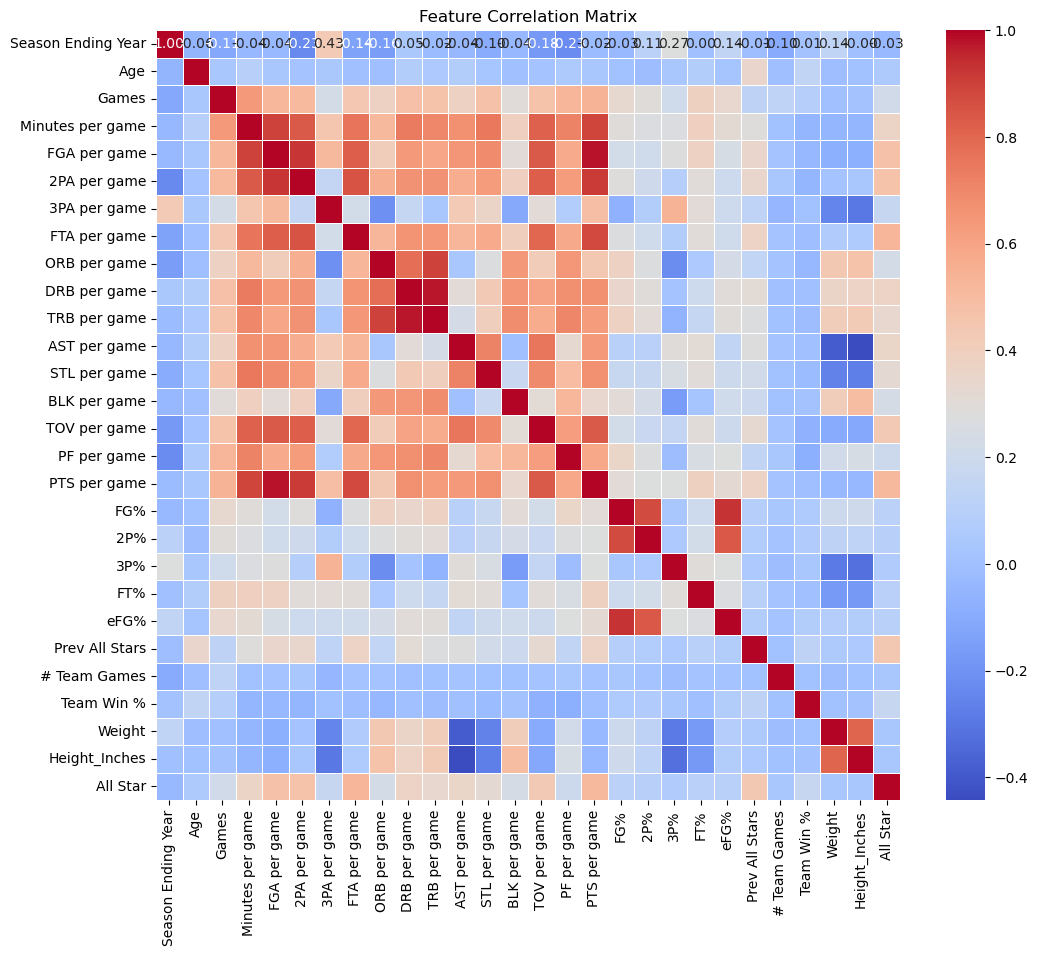

In [6]:

plt.figure(figsize=(12, 10))
# Calculate correlations
corr = df.select_dtypes(include=[np.number]).corr()

# Create the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Data Cleaning and Processing: 

# Models: 

# Results and Comparisons

# Conclusions and Final Remarks: 

# Data Sources

We aggregate multiple datasets to build a unified dataset of NBA team and player statistics.

## Team Data
- **Team Records Dataset**  
  Source: NBA Season Records from Every Year (Kaggle)  
  File: `Team_Records`  

- **Team Abbreviation Mapping**  
  Source: Historical NBA Data and Player Box Scores (Kaggle)  
  File: `TeamHistories.csv`  

## Player Data
- **Modern Player Data (1996–2023)**  
  Source: NBA Players Data (Kaggle)  
  File: `all_seasons.csv`  

- **Historical Player Data (1950–2017)**  
  Source: NBA Players Stats (Kaggle)  
  File: `player_data.csv`  

## Supplementary Sources
- Basketball Reference: https://www.basketball-reference.com  
- Stathead Player Season Finder:  
  https://www.sports-reference.com/stathead/basketball/player-season-finder.cgi  

These sources were used to:
- Fill missing seasons
- Validate inconsistencies
- Cross-check player and team statistics

---

## Data Coverage

We combine datasets across overlapping time periods:

$$
\text{Total Coverage} = [1950, 2023]
$$

with:
- Historical dataset: \(1950 \leq t \leq 2017\)
- Modern dataset: \(1996 \leq t \leq 2023\)

---

## Data Cleaning Notes

- Resolved team naming inconsistencies using `TeamHistories.csv`
- Imputed missing values using external references
- Standardized feature formats across datasets